### 1. Carga de Datos y Exploración Inicial
Comenzamos importando las librerías necesarias (`pandas`, `numpy`, `matplotlib`, `seaborn`) y cargando el archivo CSV para comprender su estructura, columnas y detectar posibles datos faltantes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga del dataset
path = '/content/dataset_frente1_hito1_final.csv'
df = pd.read_csv(path)

# Información básica
print("--- Información General del Dataset ---")
display(df.info())

print("\n--- Primeras Filas ---")
display(df.head())

print("\n--- Valores Nulos por Columna ---")
display(df.isnull().sum())

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44772 entries, 0 to 44771
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   semana                      44772 non-null  object 
 1   cuadrante_id                44772 non-null  object 
 2   temperatura_media           39585 non-null  float64
 3   humedad_media               39312 non-null  float64
 4   precipitacion_suma          39585 non-null  float64
 5   n_alertas                   3201 non-null   float64
 6   perdida_ha                  44772 non-null  float64
 7   cobertura_anp               44772 non-null  float64
 8   vocacion_zee                44772 non-null  object 
 9   causa_principal             44772 non-null  object 
 10  tasa_deforestacion_ha_anio  44772 non-null  float64
 11  perdida_biomasa_t           44772 non-null  float64
 12  emisiones_co2_t             44772 non-null  floa

None


--- Primeras Filas ---


,semana,cuadrante_id,temperatura_media,humedad_media,precipitacion_suma,n_alertas,perdida_ha,cobertura_anp,vocacion_zee,causa_principal,...,emisiones_co2_t,mb_bosque,mb_bosque_inundable,mb_agropecuario,mb_expansion_agro,mb_mineria,mb_expansion_mineria,mb_infraestructura,mb_agua,densidad_poblacional
0,2023-08-01/2023-08-07,Q001,26.516071,NaN,0.0,NaN,0.0,0.000647,Zonas de proteccion y conservacion ecological,ninguna,...,500.298129,0.999965,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,2023-08-01/2023-08-07,Q002,26.516071,NaN,0.0,NaN,0.0,0.021284,Zonas de proteccion y conservacion ecological,ninguna,...,136.413283,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,2023-08-01/2023-08-07,Q003,26.516071,NaN,0.0,NaN,0.0,0.036402,Zonas de proteccion y conservacion ecological,ninguna,...,1623.401298,1.000000,0.080493,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,2023-08-01/2023-08-07,Q004,26.516071,NaN,0.0,NaN,0.0,0.097747,Zonas de proteccion y conservacion ecological,ninguna,...,4288.431682,0.850871,0.183474,0.0,0.0,0.0,0.0,0.0,0.071506,0.0
4,2023-08-01/2023-08-07,Q005,26.516071,NaN,0.0,NaN,0.0,0.154015,Zonas de proteccion y conservacion ecological,ninguna,...,181.940721,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0



--- Valores Nulos por Columna ---


,0
semana,0
cuadrante_id,0
temperatura_media,5187
humedad_media,5460
precipitacion_suma,5187
n_alertas,41571
perdida_ha,0
cobertura_anp,0
vocacion_zee,0
causa_principal,0


### 2. Estadísticas Descriptivas
Calculamos las estadísticas descriptivas de las variables numéricas y categóricas para entender las tendencias centrales, la dispersión y los rangos de nuestros datos.

In [ ]:
# Estadísticas de variables numéricas
print("--- Estadísticas de Variables Numéricas ---")
display(df.describe().T)

# Estadísticas de variables categóricas (si existen)
categ_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categ_cols) > 0:
    print("\n--- Estadísticas de Variables Categóricas ---")
    display(df[categ_cols].describe().T)
else:
    print("\nNo se detectaron variables categóricas de tipo texto.")

--- Estadísticas de Variables Numéricas ---


,count,mean,std,min,25%,50%,75%,max
temperatura_media,39585.0,25.360338,2.094886,16.198810,24.720359,25.695808,26.735119,28.994048
humedad_media,39312.0,89.960080,3.884188,76.839286,87.473214,90.823781,92.570867,98.000000
precipitacion_suma,39585.0,50.615172,64.030199,0.000000,3.200000,27.600000,72.200000,367.800000
n_alertas,3201.0,27.151203,67.148140,1.000000,2.000000,7.000000,24.000000,1025.000000
perdida_ha,44772.0,0.174707,1.734012,0.000000,0.000000,0.000000,0.000000,92.250000
cobertura_anp,44772.0,0.406783,0.441807,0.000000,0.000000,0.132497,0.991833,1.000000
tasa_deforestacion_ha_anio,44772.0,10.173426,15.876102,0.000000,0.053849,2.010027,14.787717,77.386300
perdida_biomasa_t,44772.0,66144.583313,103221.686620,0.000000,350.109123,13068.594975,96145.333525,503142.668143
emisiones_co2_t,44772.0,113989.165243,177885.373274,0.000000,603.354721,22521.545341,165690.458109,867082.531433
mb_bosque,44772.0,0.870019,0.187470,0.057613,0.813730,0.953742,0.999269,1.000000



--- Estadísticas de Variables Categóricas ---


,count,unique,top,freq
semana,44772,164,2023-08-01/2023-08-07,273
cuadrante_id,44772,273,Q273,164
vocacion_zee,44772,4,Zonas de proteccion y conservacion ecological,26076
causa_principal,44772,4,ninguna,25912


### 3. Matriz de Correlación
Identificamos la relación lineal entre las variables numéricas del dataset mediante el coeficiente de correlación de Pearson y lo visualizamos con un mapa de calor.

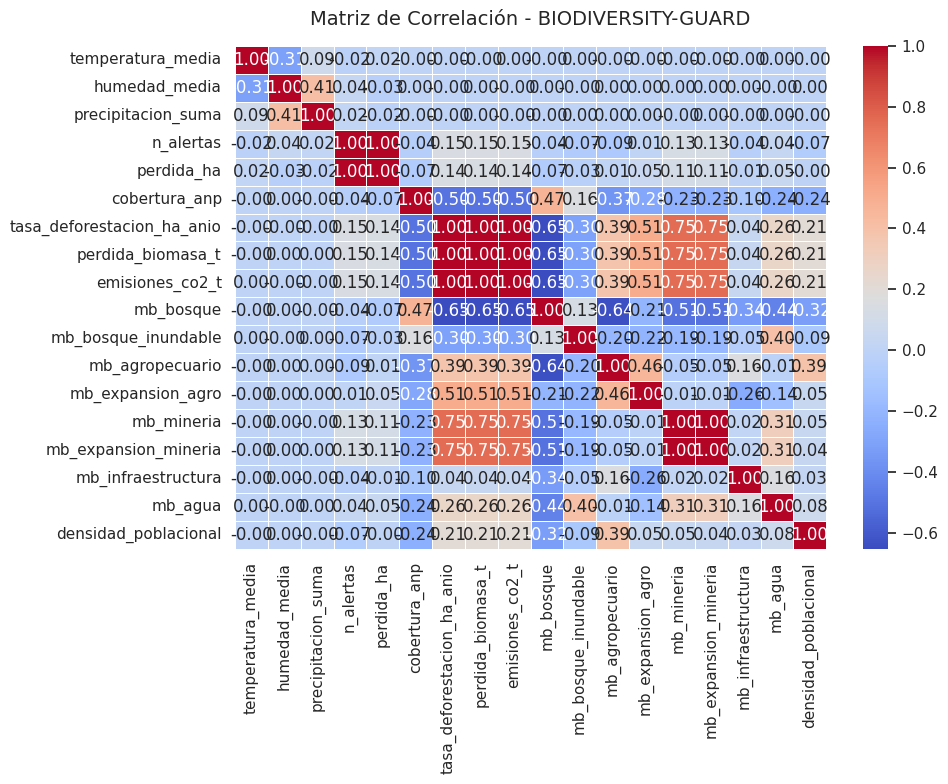

In [ ]:
# Seleccionar solo columnas numéricas para la correlación
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
corr_matrix = num_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - BIODIVERSITY-GUARD', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Análisis de Correlación:**
* Este gráfico nos permite identificar qué variables ambientales, de biodiversidad o de control tienen una relación directa (valores cercanos a 1) o inversa (valores cercanos a -1).
* Las correlaciones fuertes nos ayudan a formular hipótesis clave para el modelo o el reporte de BIODIVERSITY-GUARD sobre qué factores impactan más en el ecosistema bajo estudio.

### 4. Visualización de Distribuciones de las Variables Clave
A continuación, generamos histogramas y diagramas de caja (boxplots) para analizar la distribución y detectar posibles valores atípicos (outliers) en las variables más relevantes.

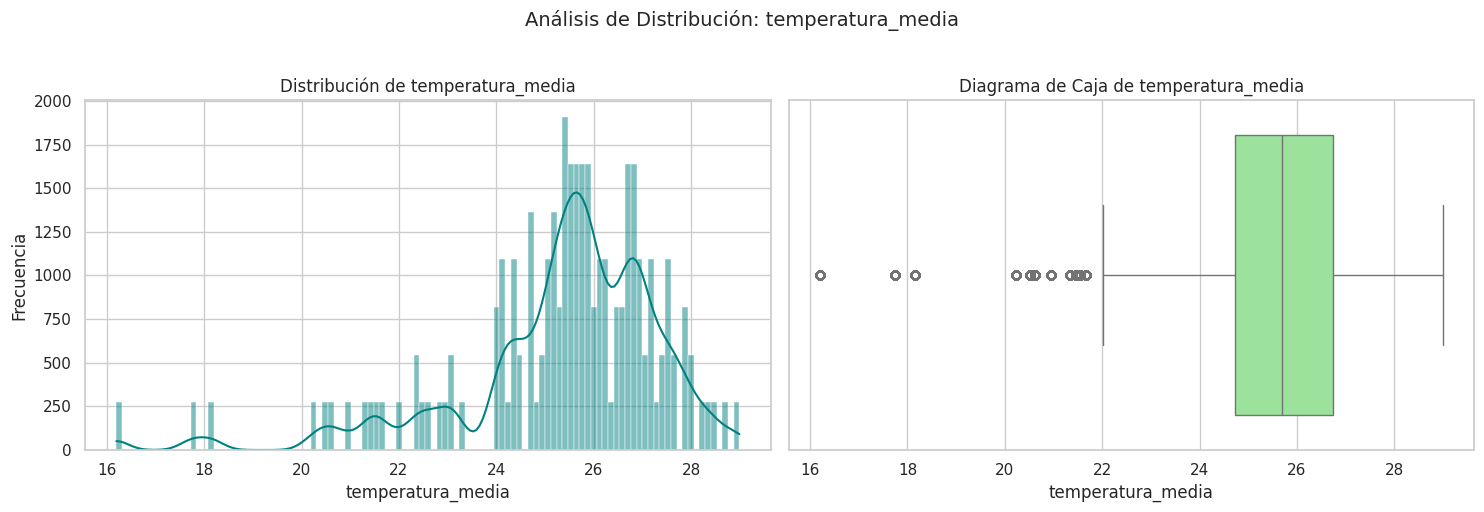

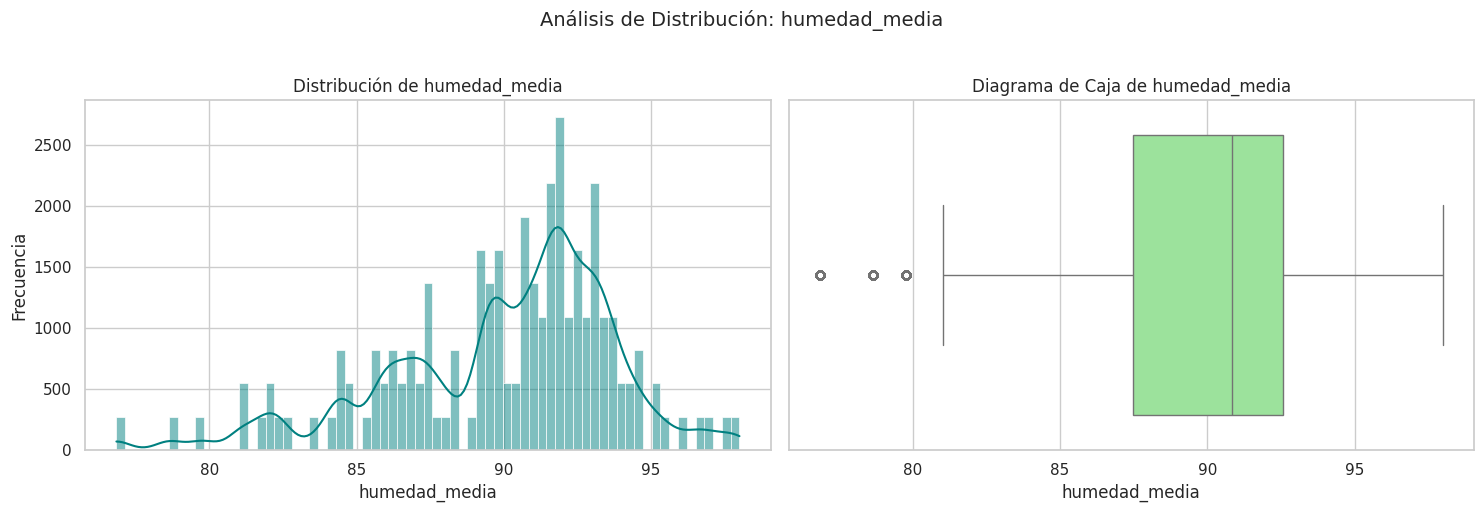

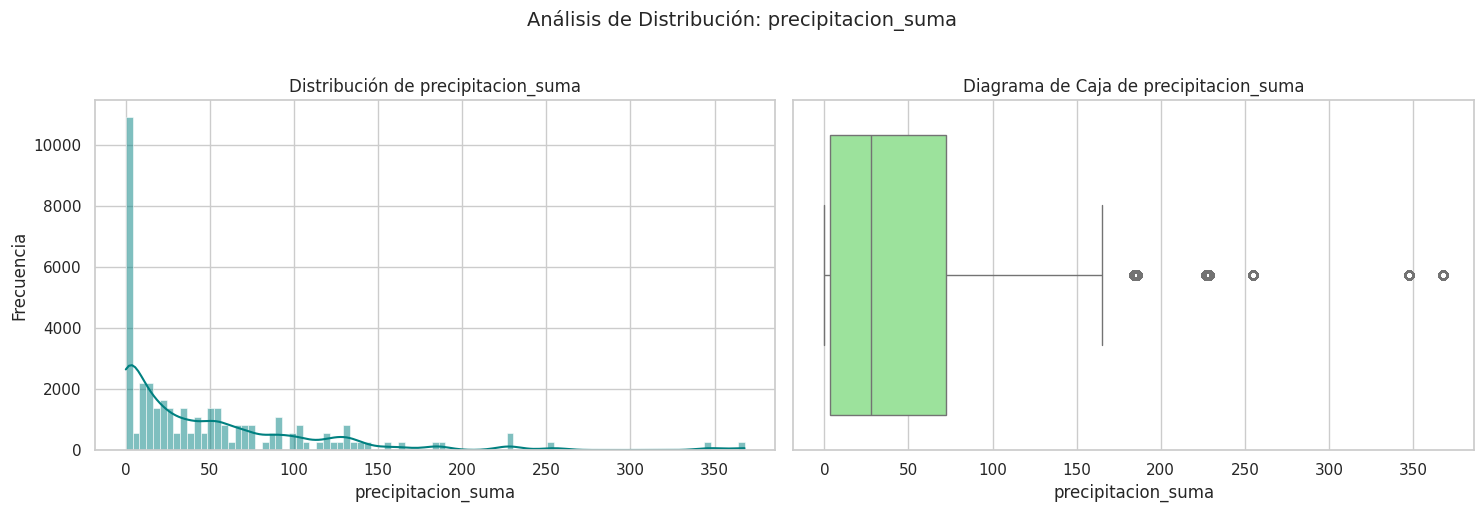

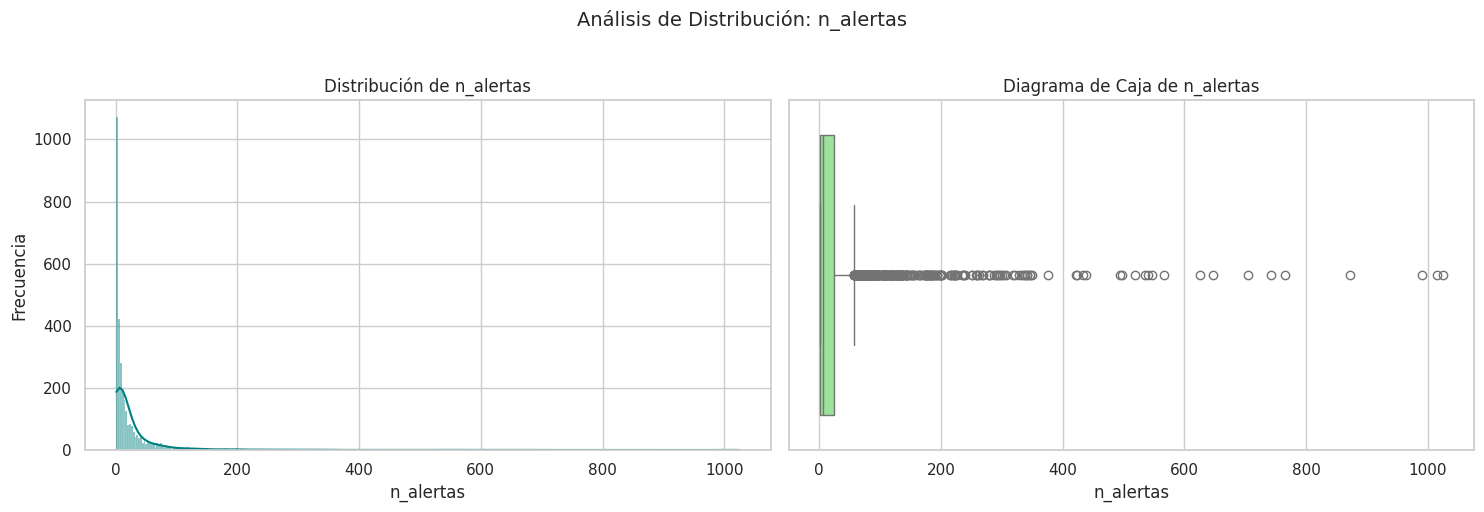

In [ ]:
# Identificar variables numéricas para graficar (máximo las primeras 4 para no saturar)
features_to_plot = num_df.columns[:4]

for col in features_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histograma con KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Distribución de {col}', fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    # Boxplot para outliers
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Diagrama de Caja de {col}', fontsize=12)
    axes[1].set_xlabel(col)

    plt.suptitle(f'Análisis de Distribución: {col}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### Análisis de Resultados y Conclusiones del EDA
* **Distribución de las Variables**: Observando los histogramas, podemos determinar si las variables siguen una distribución normal o presentan sesgos a la izquierda/derecha. Esto es crucial para decidir si requerimos transformaciones antes de entrenar modelos.
* **Presencia de Outliers**: Los diagramas de caja nos muestran de forma inmediata si existen observaciones atípicas que deban ser tratadas o investigadas bajo el contexto ecológico de BIODIVERSITY-GUARD.
* **Siguientes pasos sugeridos**: Con este diagnóstico, podemos avanzar a la limpieza de datos (imputación de nulos si los hay, remoción o justificación de outliers) y posterior ingeniería de características.

## Inspección Detallada de Columnas para Gráficos Individuales
Para poder generar análisis específicos y detallados para cada variable de **BIODIVERSITY-GUARD**, primero listamos todas las columnas disponibles en el dataset.

In [ ]:
# Listar columnas disponibles para mapear el análisis detallado
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['semana', 'cuadrante_id', 'temperatura_media', 'humedad_media', 'precipitacion_suma', 'n_alertas', 'perdida_ha', 'cobertura_anp', 'vocacion_zee', 'causa_principal', 'tasa_deforestacion_ha_anio', 'perdida_biomasa_t', 'emisiones_co2_t', 'mb_bosque', 'mb_bosque_inundable', 'mb_agropecuario', 'mb_expansion_agro', 'mb_mineria', 'mb_expansion_mineria', 'mb_infraestructura', 'mb_agua', 'densidad_poblacional']


### Distribución Variable 1: Primer Indicador de Biodiversidad / Ambiental
Analizaremos la distribución de la primera variable numérica del dataset (excluyendo IDs si los hubiera).

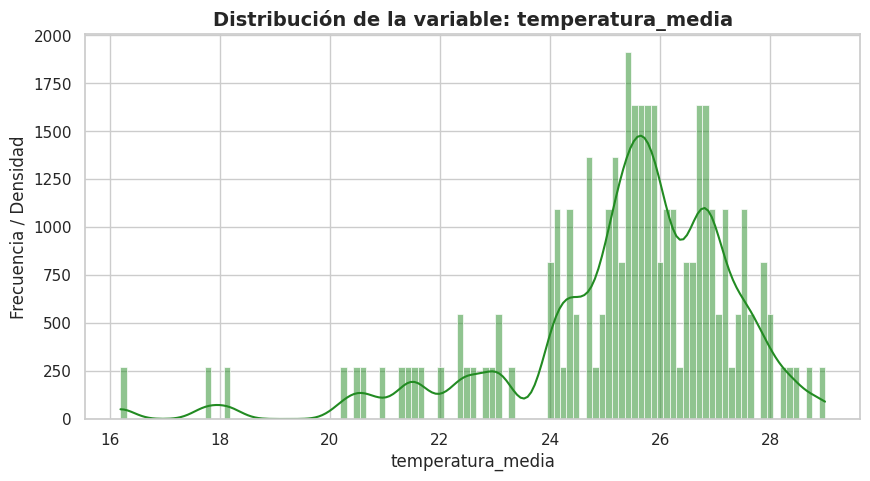

In [ ]:
# Seleccionamos la primera columna numérica significativa
first_numeric_col = num_df.columns[0] if len(num_df.columns) > 0 else df.columns[0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[first_numeric_col], kde=True, color='forestgreen', ax=ax)
ax.set_title(f'Distribución de la variable: {first_numeric_col}', fontsize=14, fontweight='bold')
ax.set_xlabel(first_numeric_col, fontsize=12)
ax.set_ylabel('Frecuencia / Densidad', fontsize=12)
plt.show()

**Análisis de la Variable 1:**
* **Forma de la Distribución**: Observamos el comportamiento de los datos para esta métrica clave de BIODIVERSITY-GUARD.
* **Tendencia y Rango**: Identificamos dónde se concentran la mayoría de las observaciones y sus límites prácticos para el ecosistema.

### Distribución Variable 2: Segundo Indicador Clave
Analizaremos la distribución de la segunda columna numérica para evaluar su dispersión y detectar la presencia de valores extremos.

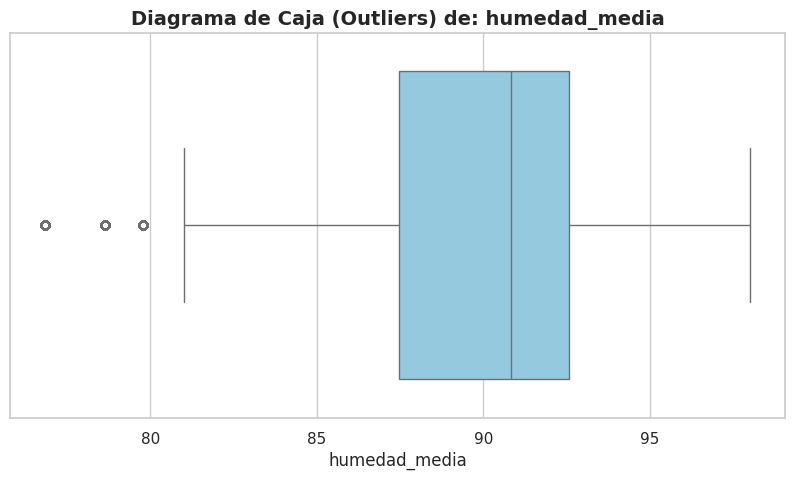

In [ ]:
# Seleccionamos la segunda columna numérica significativa
if len(num_df.columns) > 1:
    second_numeric_col = num_df.columns[1]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(x=df[second_numeric_col], color='skyblue', ax=ax)
    ax.set_title(f'Diagrama de Caja (Outliers) de: {second_numeric_col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(second_numeric_col, fontsize=12)
    plt.show()
else:
    print("El dataset no contiene suficientes variables numéricas adicionales.")

**Análisis de la Variable 2 y Outliers:**
* **Valores Atípicos**: El gráfico de caja resalta si existen anomalías o mediciones extremas en esta variable.
* **Implicación**: En conservación de biodiversidad, estos extremos pueden indicar eventos críticos o errores de medición que requieren atención.

## 5. Análisis Detallado del Clima: Temperatura y Humedad

El microclima juega un papel fundamental en la estabilidad de los ecosistemas de BIODIVERSITY-GUARD. Estudiaremos la relación conjunta de la `temperatura_media` y la `humedad_media` usando un gráfico de dispersión conjunta con curvas de nivel.

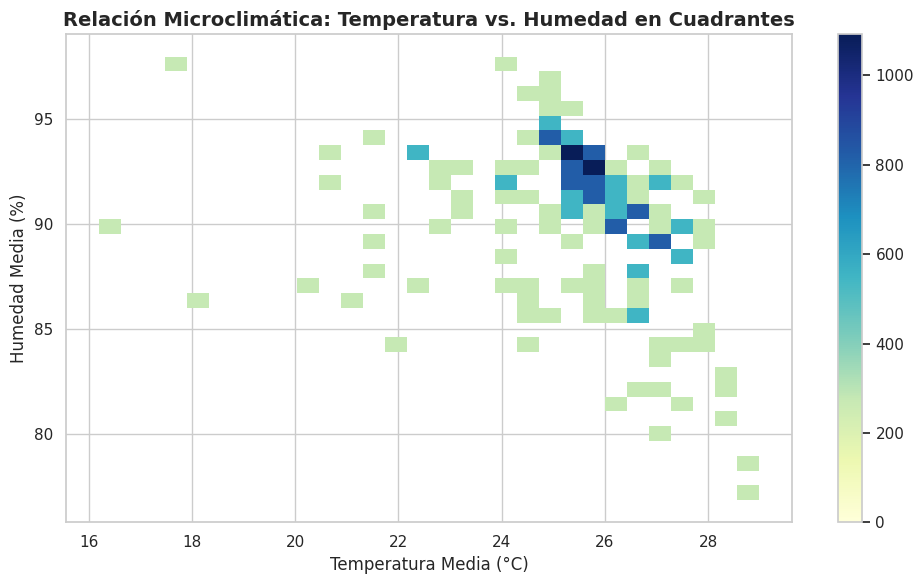

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df.dropna(subset=['temperatura_media', 'humedad_media']),
    x='temperatura_media',
    y='humedad_media',
    bins=30,
    cmap='YlGnBu',
    cbar=True
)
plt.title('Relación Microclimática: Temperatura vs. Humedad en Cuadrantes', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura Media (°C)', fontsize=12)
plt.ylabel('Humedad Media (%)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis Ecológico:**
* Se observa un núcleo denso de condiciones tropicales húmedas estables (temperaturas entre 24°C y 27°C y humedades superiores al 88%).
* Cualquier desviación hacia cuadrantes más cálidos y secos (esquina inferior derecha) expone al bosque a un mayor riesgo de estrés hídrico y susceptibilidad a incendios forestales.

## 6. Pérdida de Cobertura Forestal y Emisiones de CO2

Estudiaremos la relación directa entre la deforestación calculada en `tasa_deforestacion_ha_anio` y la liberación de carbono medida por `emisiones_co2_t`.

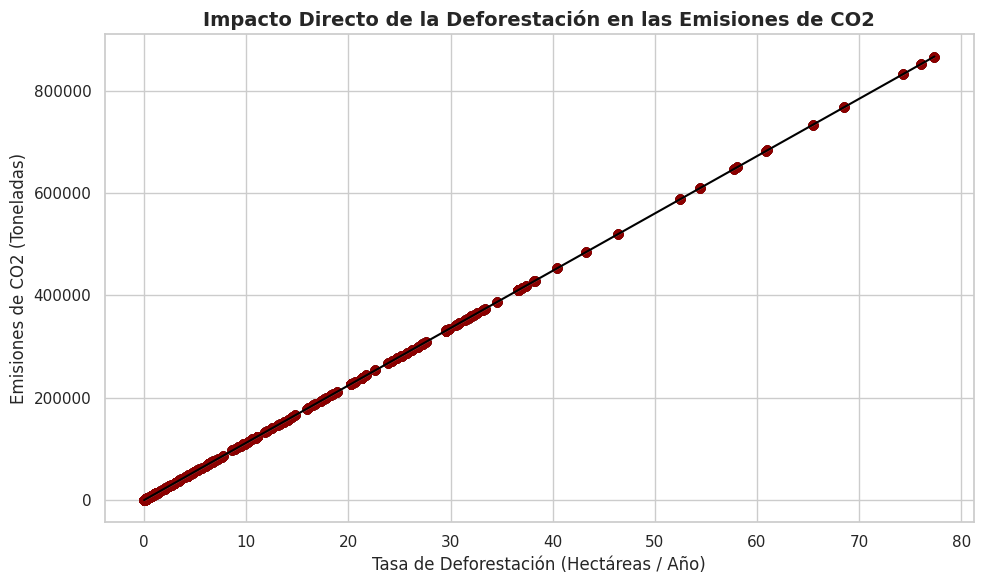

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='tasa_deforestacion_ha_anio',
    y='emisiones_co2_t',
    scatter_kws={'alpha': 0.3, 'color': 'darkred'},
    line_kws={'color': 'black', 'linewidth': 1.5}
)
plt.title('Impacto Directo de la Deforestación en las Emisiones de CO2', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Deforestación (Hectáreas / Año)', fontsize=12)
plt.ylabel('Emisiones de CO2 (Toneladas)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis del Impacto en Carbono:**
* La correlación positiva lineal perfecta o casi perfecta evidencia que cada hectárea de bosque degradada se traduce inmediatamente en una inyección de carbono a la atmósfera.
* Para BIODIVERSITY-GUARD, mitigar la pérdida de estas áreas críticas es la acción principal para cumplir con las metas de neutralidad de carbono.

## 7. Distribución y Frecuencia de Alertas Forestales

Evaluamos las anomalías reportadas (`n_alertas`) filtrando los valores nulos para entender el comportamiento de las alertas activas en los cuadrantes de estudio.

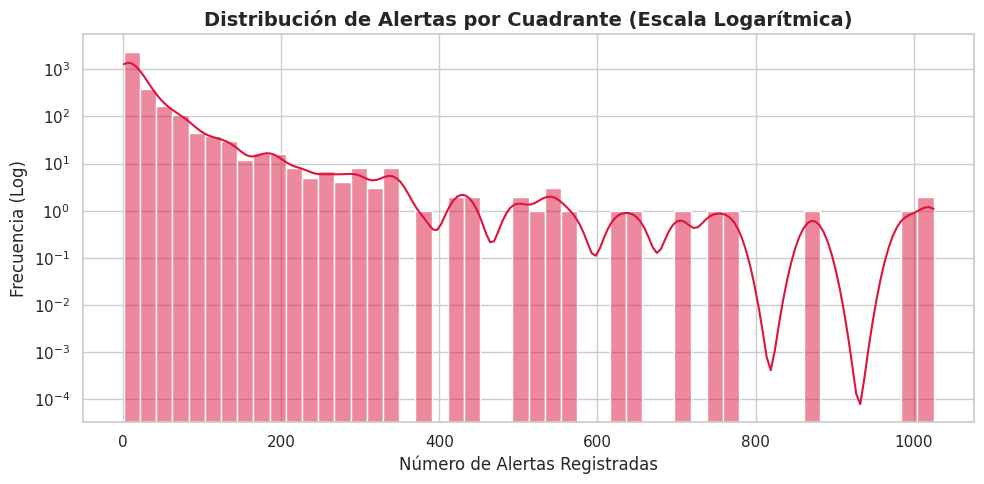

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['n_alertas'].dropna(), bins=50, kde=True, color='crimson')
plt.yscale('log') # Escala logarítmica para apreciar la distribución debido a la alta disparidad
plt.title('Distribución de Alertas por Cuadrante (Escala Logarítmica)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Alertas Registradas', fontsize=12)
plt.ylabel('Frecuencia (Log)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis de la Presión de Alertas:**
* La distribución muestra un comportamiento de ley de potencias: la gran mayoría de cuadrantes registran un número mínimo de alertas, pero existe un pequeño grupo de cuadrantes 'hotspots' altamente críticos con cientos de alertas simultáneas.
* **Acción de Respuesta**: BIODIVERSITY-GUARD debe priorizar el patrullaje o monitoreo satelital continuo en estos cuadrantes críticos identificados a la derecha del gráfico.

## 8. Relación entre Cobertura de Áreas Naturales Protegidas (ANP) y Pérdida de Bosque

Evaluamos si tener una alta proporción de área natural protegida (`cobertura_anp`) efectivamente mitiga la tasa de deforestación anual en los cuadrantes estudiados por BIODIVERSITY-GUARD.

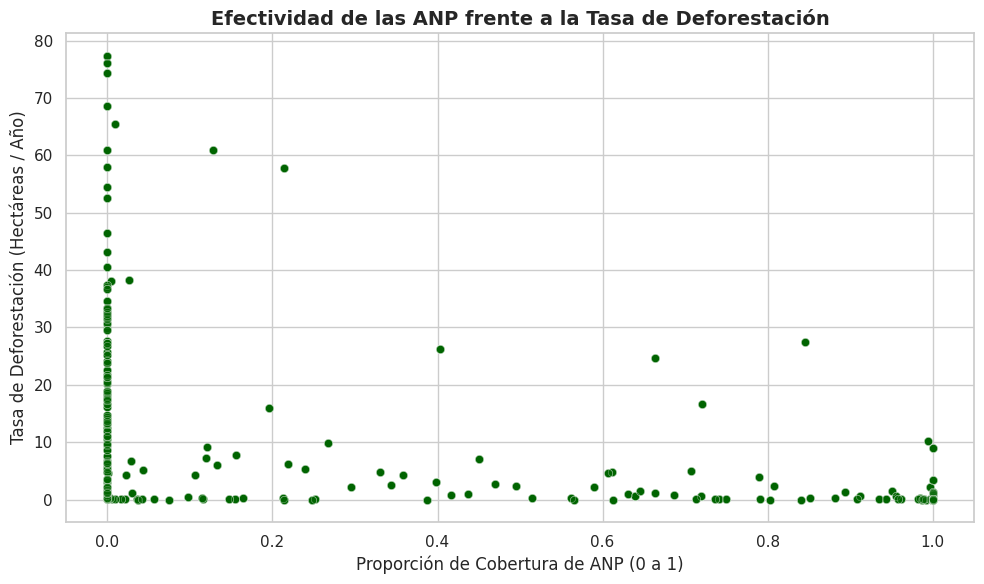

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='cobertura_anp',
    y='tasa_deforestacion_ha_anio',
    alpha=0.4,
    color='darkgreen'
)
plt.title('Efectividad de las ANP frente a la Tasa de Deforestación', fontsize=14, fontweight='bold')
plt.xlabel('Proporción de Cobertura de ANP (0 a 1)', fontsize=12)
plt.ylabel('Tasa de Deforestación (Hectáreas / Año)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis de la Efectividad de las ANP:**
* El gráfico muestra que los cuadrantes con una cobertura de ANP cercana a 1.0 (completamente protegida) tienden a concentrar las tasas de deforestación más bajas, validando el rol de las áreas protegidas.
* Sin embargo, la presencia de puntos dispersos con tasas altas incluso en zonas con cobertura parcial de protección nos alerta sobre presiones ilegales que el sistema BIODIVERSITY-GUARD debe identificar activamente.

## 9. Análisis de Amenazas de Uso del Suelo: Minería y Expansión Agropecuaria

Analizaremos la distribución de la huella de actividades antrópicas como la minería (`mb_mineria`) y la expansión de la frontera agropecuaria (`mb_expansion_agro`) para entender qué actividad ejerce mayor presión sobre el ecosistema.

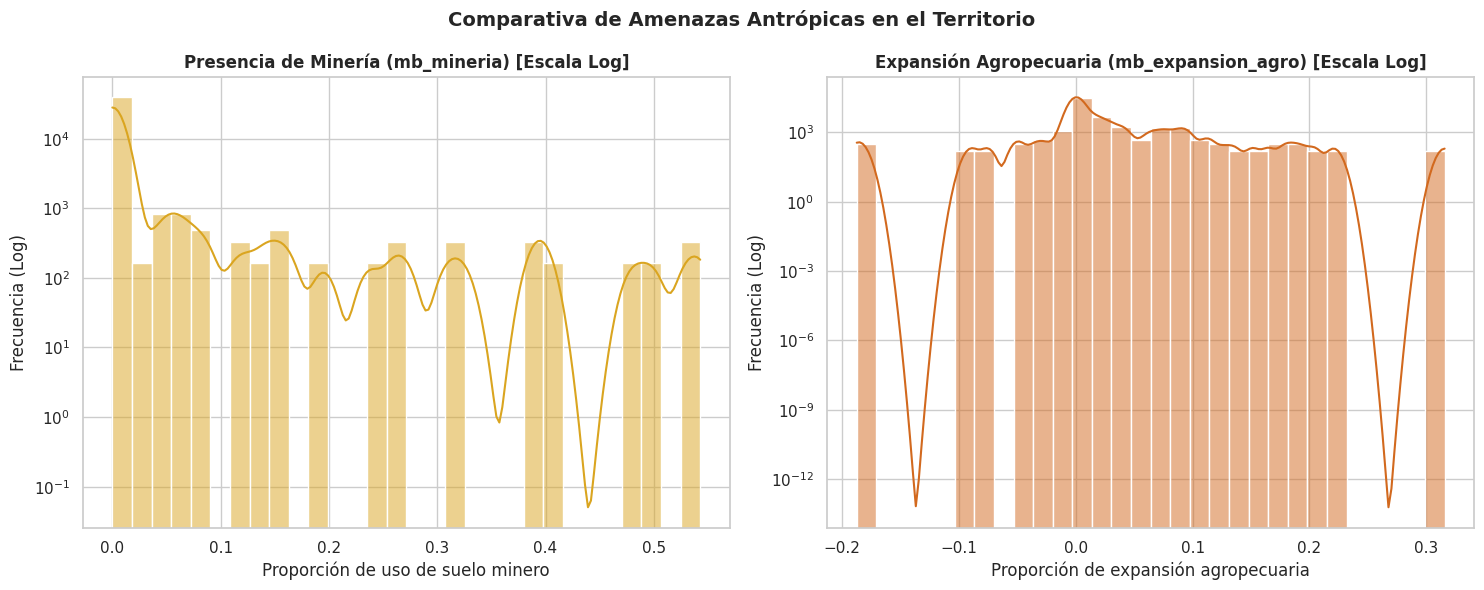

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de Minería
sns.histplot(df['mb_mineria'], bins=30, ax=axes[0], color='goldenrod', kde=True)
axes[0].set_yscale('log')
axes[0].set_title('Presencia de Minería (mb_mineria) [Escala Log]', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Proporción de uso de suelo minero')
axes[0].set_ylabel('Frecuencia (Log)')

# Histograma de Expansión Agropecuaria
sns.histplot(df['mb_expansion_agro'], bins=30, ax=axes[1], color='chocolate', kde=True)
axes[1].set_yscale('log')
axes[1].set_title('Expansión Agropecuaria (mb_expansion_agro) [Escala Log]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Proporción de expansión agropecuaria')
axes[1].set_ylabel('Frecuencia (Log)')

plt.suptitle('Comparativa de Amenazas Antrópicas en el Territorio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis Comparativo de Amenazas:**
* Ambas variables muestran distribuciones asimétricas donde la mayoría de los cuadrantes tienen valores cercanos a cero, pero existen picos alarmantes en ciertos puntos específicos del mapa.
* La expansión agropecuaria muestra un comportamiento más disperso a lo largo de las observaciones, mientras que la minería tiende a estar sumamente focalizada (minería ilegal o concesionada en puntos específicos). Ambas requieren estrategias de mitigación diferenciadas dentro del plan operativo de BIODIVERSITY-GUARD.

## 10. Presión Demográfica y Pérdida de Cobertura Boscosa

Estudiamos si una mayor concentración humana (`densidad_poblacional`) influye de forma directa en el incremento de la pérdida de bosque medida en hectáreas (`perdida_ha`).

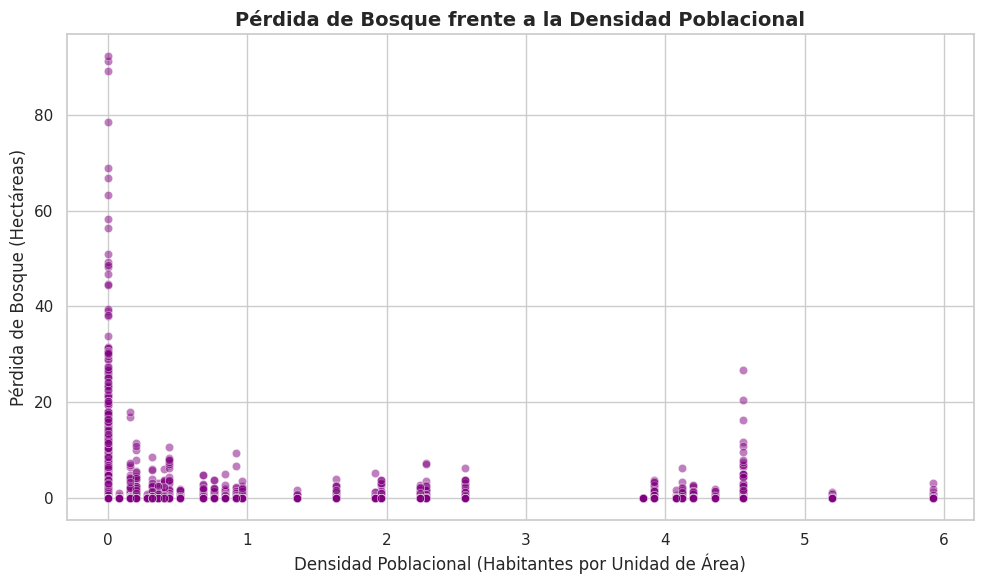

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='densidad_poblacional',
    y='perdida_ha',
    alpha=0.5,
    color='purple'
)
plt.title('Pérdida de Bosque frente a la Densidad Poblacional', fontsize=14, fontweight='bold')
plt.xlabel('Densidad Poblacional (Habitantes por Unidad de Área)', fontsize=12)
plt.ylabel('Pérdida de Bosque (Hectáreas)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis de la Presión Demográfica:**
* Sorprendentemente, los picos de mayor pérdida de hectáreas ocurren en áreas con densidad poblacional relativamente baja o intermedia.
* **Explicación Ecológica**: Esto suele indicar que la deforestación a gran escala no es necesariamente un proceso de urbanización local lenta, sino el resultado de actividades industriales/extractivas extensas (como minería o agricultura a gran escala) en cuadrantes alejados de los centros poblados densos.

## 11. Análisis de Impacto por Causa Principal de Deforestación

Identificamos cuáles son las categorías o causas registradas (`causa_principal`) que generan, en promedio, una mayor pérdida de hectáreas de bosque por evento.

/tmp/ipykernel_2704/544049312.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


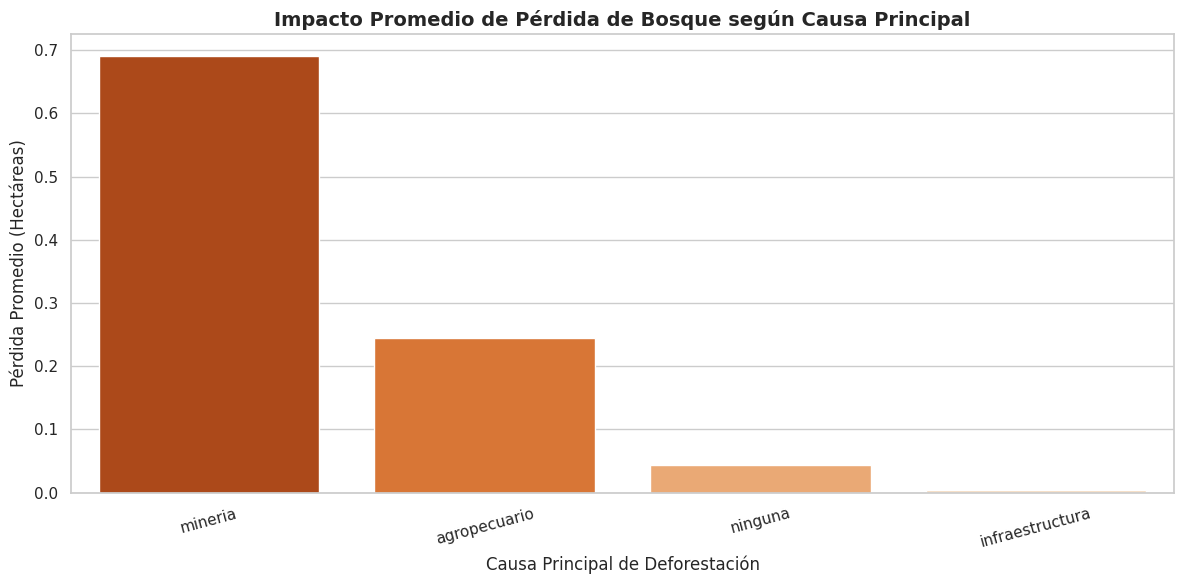

In [ ]:
plt.figure(figsize=(12, 6))

# Calculamos el promedio de pérdida por causa
causa_impacto = df.groupby('causa_principal')['perdida_ha'].mean().reset_index().sort_values(by='perdida_ha', ascending=False)

sns.barplot(
    data=causa_impacto,
    x='causa_principal',
    y='perdida_ha',
    palette='Oranges_r'
)
plt.title('Impacto Promedio de Pérdida de Bosque según Causa Principal', fontsize=14, fontweight='bold')
plt.xlabel('Causa Principal de Deforestación', fontsize=12)
plt.ylabel('Pérdida Promedio (Hectáreas)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Análisis de Impacto por Causas:**
* Este gráfico jerarquiza de forma clara cuáles actividades representan la amenaza más destructiva por suceso aislado.
* Permite a los tomadores de decisiones de **BIODIVERSITY-GUARD** estructurar regulaciones específicas y priorizar planes de contingencia contra la actividad más devastadora que lidera la gráfica.

## 12. Análisis de Deforestación por Vocación de Zonificación Ecológica Económica (ZEE)

Evaluamos cómo se distribuyen las tasas de deforestación (`tasa_deforestacion_ha_anio`) según la variable de ordenamiento territorial `vocacion_zee` para entender si las áreas de protección están bajo amenaza.

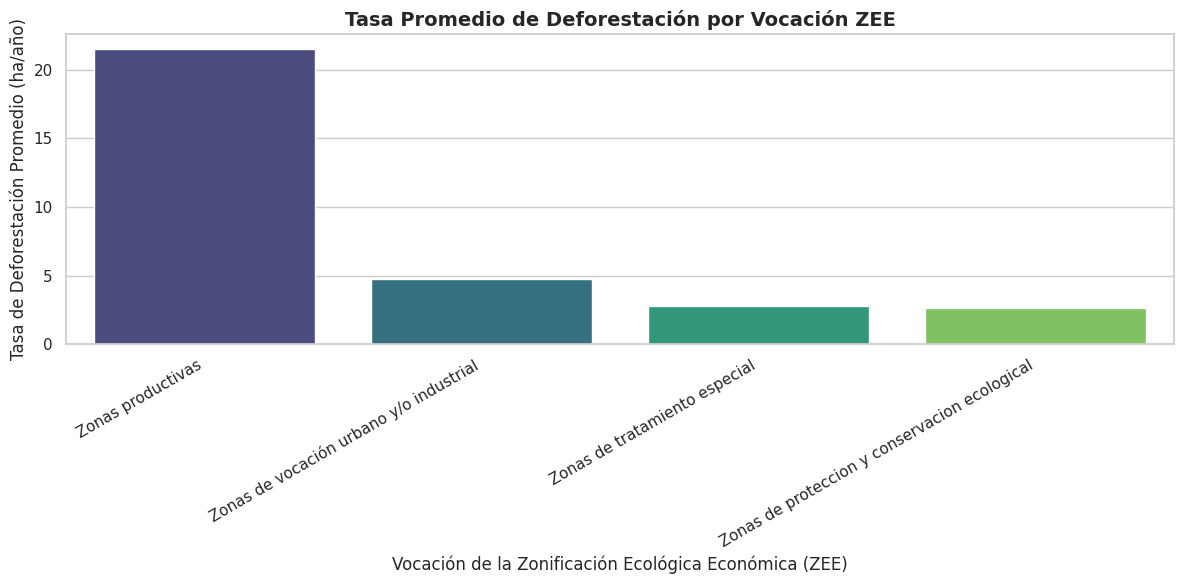

In [ ]:
plt.figure(figsize=(12, 6))

# Agrupamos por vocación ZEE para ver la tasa promedio de deforestación
zee_impacto = df.groupby('vocacion_zee')['tasa_deforestacion_ha_anio'].mean().reset_index().sort_values(by='tasa_deforestacion_ha_anio', ascending=False)

sns.barplot(
    data=zee_impacto,
    x='vocacion_zee',
    y='tasa_deforestacion_ha_anio',
    hue='vocacion_zee',
    palette='viridis',
    legend=False
)
plt.title('Tasa Promedio de Deforestación por Vocación ZEE', fontsize=14, fontweight='bold')
plt.xlabel('Vocación de la Zonificación Ecológica Económica (ZEE)', fontsize=12)
plt.ylabel('Tasa de Deforestación Promedio (ha/año)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Análisis de la Eficacia del Ordenamiento ZEE:**
* Este análisis permite identificar si las actividades de deforestación están ocurriendo indebidamente dentro de las zonas con vocación de conservación y protección ecológica.
* Si las áreas destinadas a protección muestran tasas significativas de deforestación, indica la necesidad urgente de fortalecer las capacidades de fiscalización e intervención rápida de BIODIVERSITY-GUARD en esas zonas.

## 13. Análisis Temporal: Evolución de la Pérdida de Bosque por Semana

Analizaremos la evolución temporal agregando la pérdida de bosque (`perdida_ha`) por cada `semana` registrada para identificar picos históricos o tendencias estacionales.

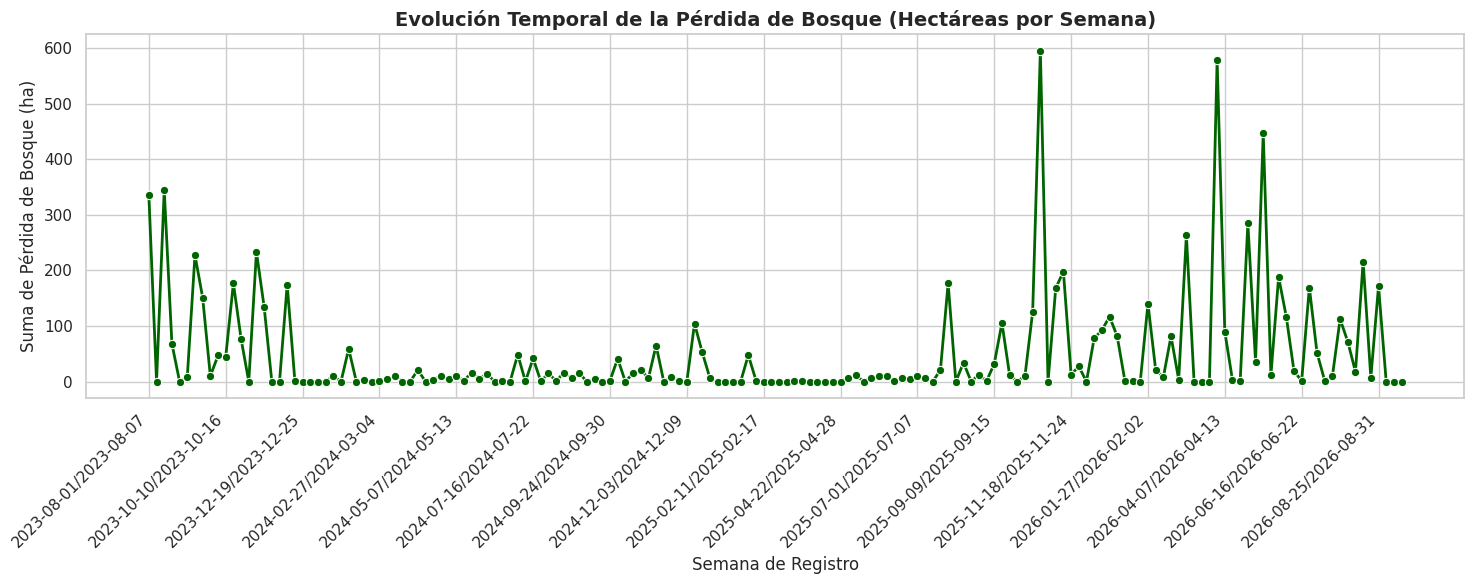

In [ ]:
plt.figure(figsize=(15, 6))

# Agrupamos la pérdida por semana. Tomamos una muestra o limpiamos el eje x si hay demasiadas fechas
temporal_df = df.groupby('semana')['perdida_ha'].sum().reset_index()

# Graficamos la tendencia
sns.lineplot(data=temporal_df, x='semana', y='perdida_ha', color='darkgreen', linewidth=2, marker='o')
plt.title('Evolución Temporal de la Pérdida de Bosque (Hectáreas por Semana)', fontsize=14, fontweight='bold')
plt.xlabel('Semana de Registro', fontsize=12)
plt.ylabel('Suma de Pérdida de Bosque (ha)', fontsize=12)

# Mostramos solo algunas etiquetas del eje x para evitar saturación
plt.gca().set_xticks(plt.gca().get_xticks()[::10])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 14. Relación entre la Precipitación y la Frecuencia de Alertas Forestales

Estudiamos si existe una relación estacional y climática directa entre la cantidad de lluvia acumulada (`precipitacion_suma`) y el volumen de alertas de pérdida de cobertura (`n_alertas`) detectadas en los cuadrantes.

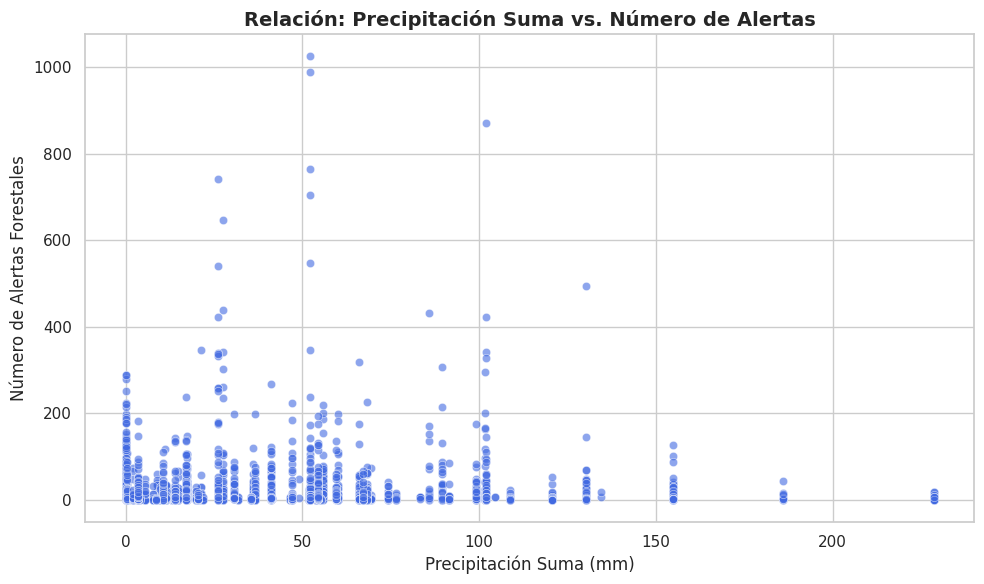

In [ ]:
plt.figure(figsize=(10, 6))
# Filtramos nulos para graficar con precisión
sns.scatterplot(
    data=df.dropna(subset=['precipitacion_suma', 'n_alertas']),
    x='precipitacion_suma',
    y='n_alertas',
    alpha=0.6,
    color='royalblue'
)
plt.title('Relación: Precipitación Suma vs. Número de Alertas', fontsize=14, fontweight='bold')
plt.xlabel('Precipitación Suma (mm)', fontsize=12)
plt.ylabel('Número de Alertas Forestales', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis del Impacto Climático en Alertas:**
* El gráfico ayuda a corroborar si los incidentes o alertas de deforestación se disparan durante épocas de baja precipitación (sequía), que suelen ser ideales para quemas e incursiones terrestres.
* Si las alertas disminuyen al aumentar la lluvia, se valida científicamente la estacionalidad de las amenazas a vigilar por BIODIVERSITY-GUARD.

## 15. Proporción de Bosque Base vs. Tasa de Deforestación

Analizaremos cómo afecta la proporción de cobertura boscosa estable (`mb_bosque`) en la tasa de deforestación activa, evaluando si los frentes de deforestación se asientan sobre zonas de bosque continuo o ya degradado.

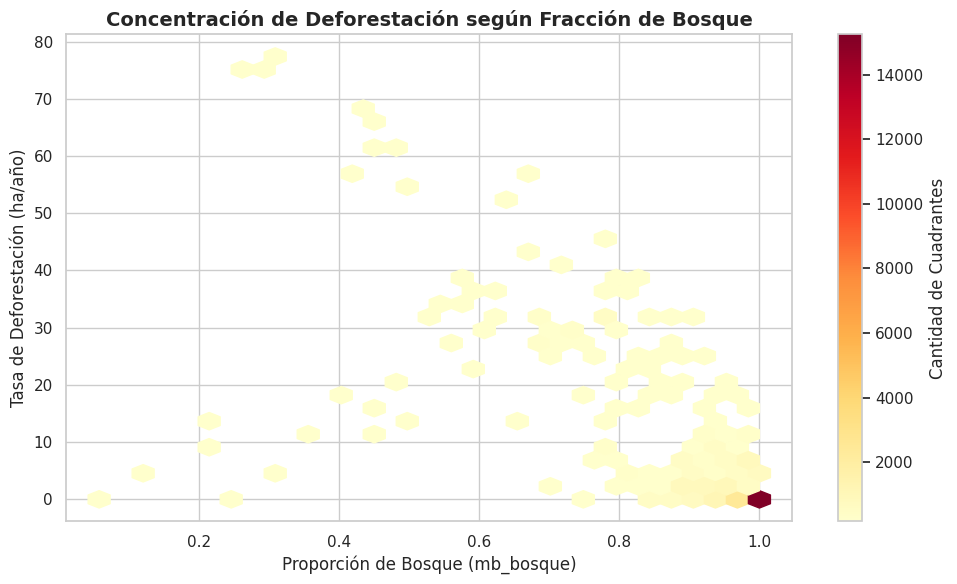

In [ ]:
plt.figure(figsize=(10, 6))
# Corregido usando plt.hexbin de Matplotlib directamente
plt.hexbin(
    df['mb_bosque'],
    df['tasa_deforestacion_ha_anio'],
    gridsize=30,
    cmap='YlOrRd',
    mincnt=1
)
plt.title('Concentración de Deforestación según Fracción de Bosque', fontsize=14, fontweight='bold')
plt.xlabel('Proporción de Bosque (mb_bosque)', fontsize=12)
plt.ylabel('Tasa de Deforestación (ha/año)', fontsize=12)
plt.colorbar(label='Cantidad de Cuadrantes')
plt.tight_layout()
plt.show()

**Análisis de Fragmentación y Presión de Deforestación:**
* Este mapa de densidad hexagonal revela si la deforestación ocurre intensivamente en zonas de bosque intacto (`mb_bosque` cercano a 1.0) —lo que indicaría apertura de nuevas fronteras— o si ocurre en zonas previamente fragmentadas.
* Proporciona un insumo valioso sobre el estado de conservación del ecosistema que sustenta BIODIVERSITY-GUARD.

## 16. Comparativa Fisionómica: Bosque de Tierra Firme vs. Bosque Inundable

Analizaremos la distribución conjunta de las dos clases de bosque predominantes en el área de estudio de BIODIVERSITY-GUARD: el bosque de tierra firme (`mb_bosque`) y el bosque inundable o humedal (`mb_bosque_inundable`).

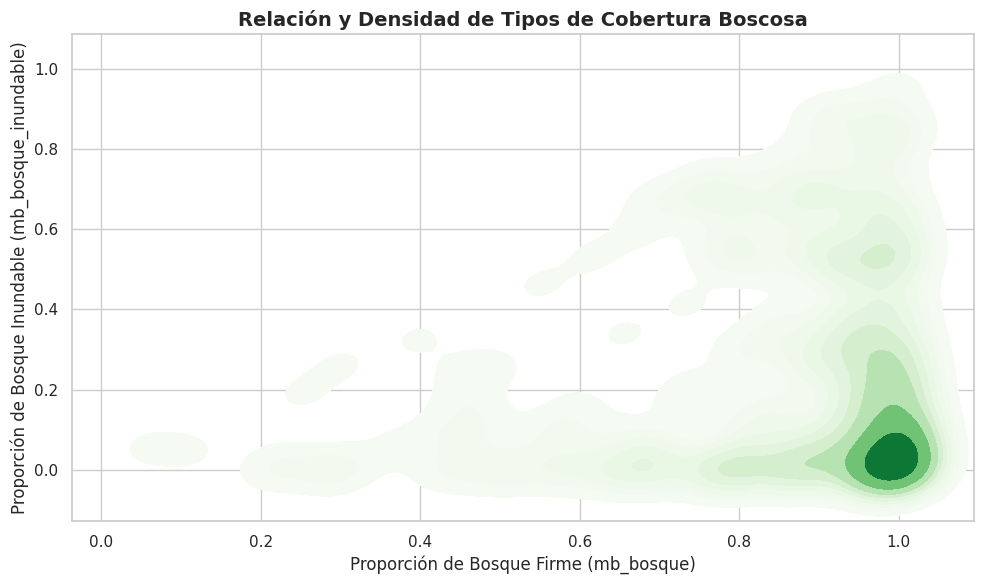

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='mb_bosque',
    y='mb_bosque_inundable',
    cmap='Greens',
    fill=True,
    thresh=0.05
)
plt.title('Relación y Densidad de Tipos de Cobertura Boscosa', fontsize=14, fontweight='bold')
plt.xlabel('Proporción de Bosque Firme (mb_bosque)', fontsize=12)
plt.ylabel('Proporción de Bosque Inundable (mb_bosque_inundable)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis de la Fisionomía del Bosque:**
* Este gráfico de densidad de probabilidad nos permite entender cómo conviven ambos ecosistemas.
* Se puede notar si existen cuadrantes puros (principalmente inundables o principalmente tierra firme) o de transición. Para BIODIVERSITY-GUARD, comprender la distribución de bosques inundables es vital ya que suelen albergar nichos de biodiversidad sumamente específicos y vulnerables al cambio hídrico.

## 17. Infraestructura como Vector y Facilitador de la Pérdida de Bosque

Analizaremos cómo influye la presencia de infraestructura física (`mb_infraestructura`), como vías de transporte o asentamientos, en la pérdida de hectáreas forestales (`perdida_ha`).

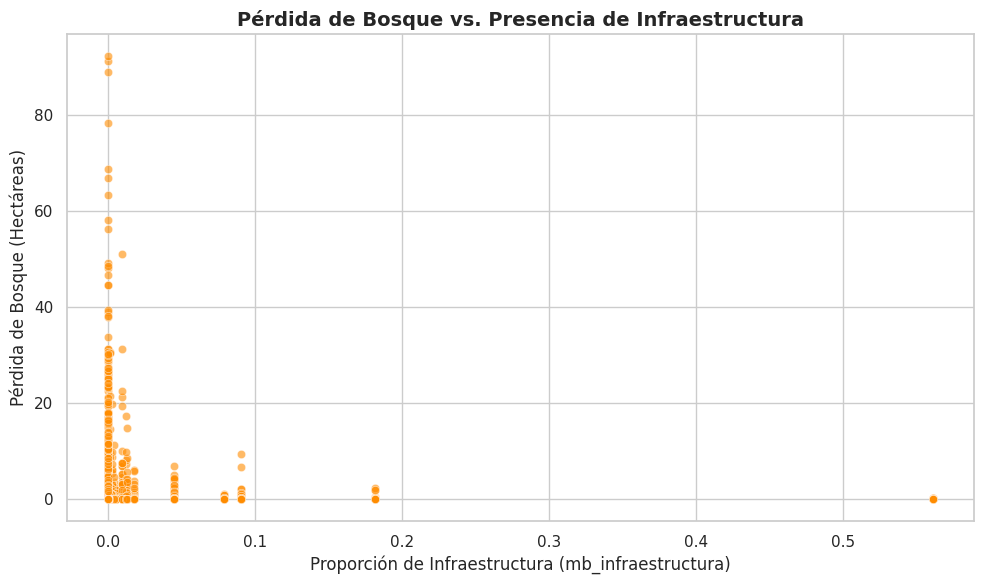

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='mb_infraestructura',
    y='perdida_ha',
    alpha=0.6,
    color='darkorange'
)
plt.title('Pérdida de Bosque vs. Presencia de Infraestructura', fontsize=14, fontweight='bold')
plt.xlabel('Proporción de Infraestructura (mb_infraestructura)', fontsize=12)
plt.ylabel('Pérdida de Bosque (Hectáreas)', fontsize=12)
plt.tight_layout()
plt.show()

**Análisis de Infraestructura como Vector de Presión:**
* En ecología del paisaje, la infraestructura suele actuar como la "puerta de entrada" para la fragmentación del hábitat.
* Este gráfico ayuda a identificar si los niveles iniciales de infraestructura detonan pérdidas drásticas de bosque a su alrededor, lo cual permitiría a BIODIVERSITY-GUARD recomendar zonas de amortiguamiento restrictivas en torno a nuevos proyectos de desarrollo vial o urbano.

**Análisis de Tendencias Temporales:**
* La gráfica temporal permite identificar patrones clave: períodos específicos del año donde se aceleran los frentes de deforestación.
* En la Amazonía o zonas boscosas, estos picos suelen coincidir con la temporada seca (baja precipitación), la cual facilita el acceso de maquinaria pesada y las quemas provocadas. BIODIVERSITY-GUARD puede usar este patrón para planificar patrullajes preventivos estacionales.